Connected to base (Python 3.9.13)

Run Palantir on Larry

In [2]:
import palantir
import scanpy as sc
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from scipy.spatial import distance_matrix
import os
# Plotting

import matplotlib
import matplotlib.pyplot as plt
# warnings

import warnings
from numba.core.errors import NumbaDeprecationWarning
warnings.filterwarnings(action="ignore", category=NumbaDeprecationWarning)
warnings.filterwarnings(
    action="ignore", module="scanpy", message="No data for colormapping"
)

load data and show umap

In [3]:
adata = sc.read_h5ad("/home/yzhao4/new_repo_branchpoint/Data/Larrydata/Data/Complete_LARRY_dataset_adata_preprocessed_barcodes.h5ad")
adata

AnnData object with n_obs × n_vars = 130887 × 25289
    obs: 'n_counts', 'Time_Point', 'Source', 'Well', 'mito_frac', 'time_info', 'state_info', 'precomputed_fate_bias', 'selected_clonal_cells', 'Gata1_states'
    var: 'highly_variable'
    uns: 'clonal_time_points', 'data_des', 'max_mito', 'min_tot', 'neighbors', 'state_info_colors', 'time_info_colors', 'time_ordering', 'umap'
    obsm: 'X_clone', 'X_emb', 'X_pca', 'X_umap'

/home/yzhao4/Software/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/yzhao4/Software/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


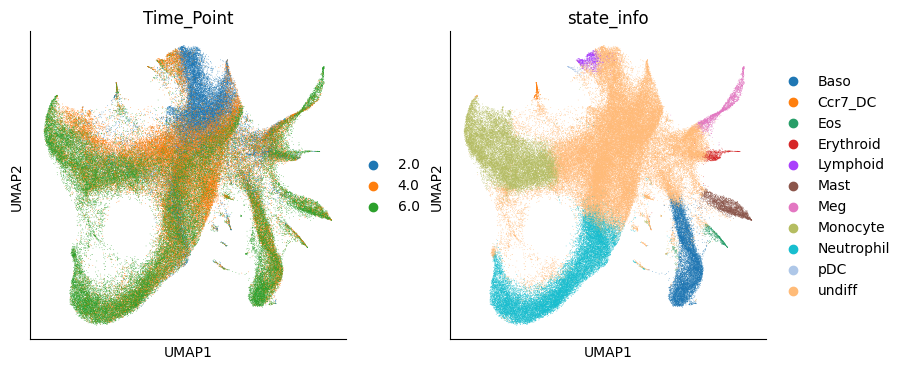

In [4]:
sc.pl.umap(adata, color=['Time_Point','state_info'])

remove pDC and Lymphoid, then show pseudotime

/home/yzhao4/Software/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/yzhao4/Software/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


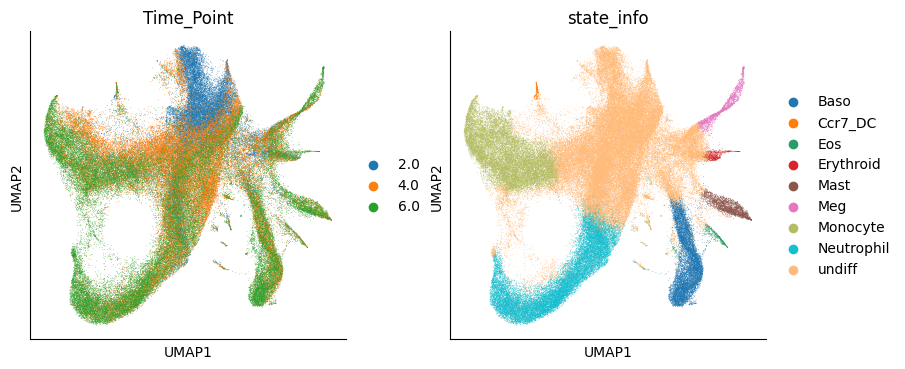

In [5]:
adata.obs['state_info'].value_counts()
celltype_mask = adata.obs['state_info'] != "pDC"
adata = adata[celltype_mask]
adata

celltype_mask = adata.obs['state_info'] != "Lymphoid"
adata = adata[celltype_mask]
adata

sc.pl.umap(adata, color=['Time_Point','state_info'])

no count matrix

In [6]:
adata.X[0:10,0:10].toarray()

array([[0.        , 1.2599825 , 0.        , 0.        , 0.        ,
        0.62999123, 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 1.0776678 , 0.        , 0.        ,
        0.        , 0.        , 0.        , 2.1553357 , 0.        ],
       [0.        , 0.        , 1.6736541 , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 5.6705947 , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 1.9747424 , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 2.231125  , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 2.5497465 , 0.       

check barcode

In [7]:
adata.obs_names[0:10]

Index(['d6_2_2:GCGTGCAA-AGAAGTTA', 'd6_2_2:AAGGGACC-CTCGATGC',
       'd6_2_2:CGTACCGA-AGCGCCTT', 'd6_2_2:CTGAAGGG-AGGAGCTT',
       'd6_2_2:CCGTAGCT-AGGCAGTT', 'd6_2_2:GGCTTTGC-CGAACGTA',
       'd6_2_2:TAGGCTTT-CGTGGATA', 'd6_2_2:GGCCCAAT-GTTTACGT',
       'd6_2_2:AAGTCGGG-GGCCTAAG', 'd6_2_2:ACGGTTGG-CAGACCAT'],
      dtype='object', name='library_barocde')

run diffusion maps

In [8]:
dm_res = palantir.utils.run_diffusion_maps(adata, n_components=30)

2025-03-30 15:25:25.594497: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2025-03-30 15:25:25.596848: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory
2025-03-30 15:25:25.596871: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Cannot dlopen some TensorRT libraries. If you would like to use Nvidia GPU with TensorRT, please make sure the missing libraries mentioned above are installed properly.
/home/yzhao4/Software/anaconda3/lib/python3.9/site-packages/palantir/utils.py:482: ImplicitModificationWarning: Setting element `.obsp['DM_Kernel']` of view, initializing view as actual.
  data.obsp[kernel_key] = res["kernel"]


determine terminal state cells

In [9]:
terminal_dict = {}

Monocyte

Quantiles at [0, 0.25, 0.5, 0.75, 1]: [-6.58657885 -5.12721872 -3.60008669 -1.81475532 14.29576302]
25575
2914
6354
d6_2_1:TACGCGAG-CAATTAGT


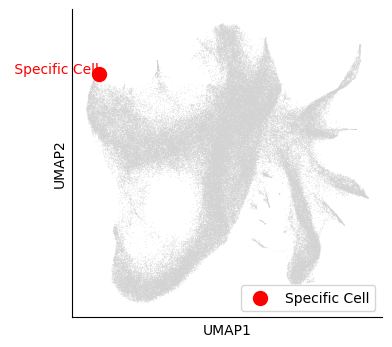

In [10]:
celltype_mask = (adata.obs['Time_Point'] == '6.0') & (adata.obs['state_info'] == 'Monocyte')
adata_subset = adata[celltype_mask]

# Define the quantiles you want to compute
quantiles = [0, 0.25, 0.5, 0.75, 1]

# Compute the quantiles
computed_quantiles = np.quantile(adata_subset.obsm['X_umap'][:,0], quantiles)

print(f"Quantiles at {quantiles}: {computed_quantiles}")

np.random.seed(42) 
num_samples=1000

matches = (adata.obs['Time_Point'] == '2.0') & (adata.obs['state_info'] == 'undiff')
idx1 = np.where(matches)[0]
print(len(idx1))
subsampled_idx1 = np.random.choice(idx1, size=num_samples, replace=False)

matches = (adata.obs['Time_Point'] == '6.0') & (adata.obs['state_info'] == 'Monocyte') & (adata.obsm['X_umap'][:,0] <= -5)
idx2 = np.where(matches)[0]
print(len(idx2))
subsampled_idx2 = np.random.choice(idx2, size=num_samples, replace=False)

# Extract the rows corresponding to idx1 and idx2
data_idx1 = dm_res['EigenVectors'].iloc[subsampled_idx1]
data_idx2 = dm_res['EigenVectors'].iloc[subsampled_idx2]

# Calculate the distance matrix between idx1 and idx2
distances = distance_matrix(data_idx1, data_idx2)

# Calculate the average distance from each cell in idx2 to all cells in idx1
average_distances = np.mean(distances, axis=0)

# Find the index of the cell in idx2 with the maximum average distance
max_avg_dist_index = np.argmax(average_distances)

# Get the actual index in the original DataFrame
furthest_cell_index = subsampled_idx2[max_avg_dist_index]
cell_name = adata.obs_names[furthest_cell_index]
print(furthest_cell_index)
print(cell_name)

terminal_dict['Monocyte'] = cell_name

sc.pl.umap(adata, show=False)  # Set show=False to keep the plot open for further annotations

# Specific cell name to find
specific_cell_name = cell_name  # Replace with your actual cell name

# Find the index of the specific cell
cell_index = adata.obs_names.get_loc(specific_cell_name)

# Retrieve UMAP coordinates
umap_coordinates = adata.obsm['X_umap'][cell_index]

# Annotate the specific cell on the plot
plt.scatter(umap_coordinates[0], umap_coordinates[1], color='red', s=100, label='Specific Cell')
plt.text(umap_coordinates[0], umap_coordinates[1], ' Specific Cell', color='red', ha='right')

plt.legend()
plt.show()


Neutrophil

Quantiles at [0, 0.25, 0.5, 0.75, 1]: [-4.54347563 -2.50811046  0.32150632  2.87255907 14.09580517]
25575
3612
LK_d6_2_2:ACCGTCGA-ATACTCTT
{'Monocyte': 'd6_2_1:TACGCGAG-CAATTAGT', 'Neutrophil': 'LK_d6_2_2:ACCGTCGA-ATACTCTT'}


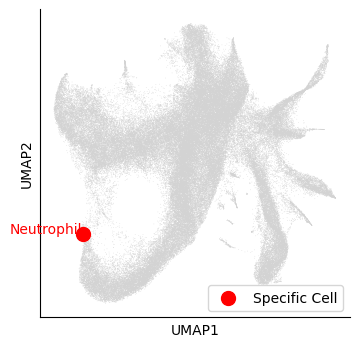

In [11]:
celltype = 'Neutrophil'
celltype_mask = (adata.obs['Time_Point'] == '6.0') & (adata.obs['state_info'] == celltype)
adata_subset = adata[celltype_mask]

# Define the quantiles you want to compute
quantiles = [0, 0.25, 0.5, 0.75, 1]

# Compute the quantiles
computed_quantiles = np.quantile(adata_subset.obsm['X_umap'][:,0], quantiles)

print(f"Quantiles at {quantiles}: {computed_quantiles}")

np.random.seed(42) 
num_samples=1000

matches = (adata.obs['Time_Point'] == '2.0') & (adata.obs['state_info'] == 'undiff')
idx1 = np.where(matches)[0]
print(len(idx1))
subsampled_idx1 = np.random.choice(idx1, size=num_samples, replace=False)

matches = (adata.obs['Time_Point'] == '6.0') & (adata.obs['state_info'] == celltype) & (adata.obsm['X_umap'][:,0] <= computed_quantiles[1])
idx2 = np.where(matches)[0]
print(len(idx2))
subsampled_idx2 = np.random.choice(idx2, size=num_samples, replace=False)

# Extract the rows corresponding to idx1 and idx2
data_idx1 = dm_res['EigenVectors'].iloc[subsampled_idx1]
data_idx2 = dm_res['EigenVectors'].iloc[subsampled_idx2]

# Calculate the distance matrix between idx1 and idx2
distances = distance_matrix(data_idx1, data_idx2)

# Calculate the average distance from each cell in idx2 to all cells in idx1
average_distances = np.mean(distances, axis=0)

# Find the index of the cell in idx2 with the maximum average distance
max_avg_dist_index = np.argmax(average_distances)

# Get the actual index in the original DataFrame
furthest_cell_index = subsampled_idx2[max_avg_dist_index]
cell_name = adata.obs_names[furthest_cell_index]
print(cell_name)

terminal_dict[celltype] = cell_name
print(terminal_dict)

sc.pl.umap(adata, show=False)  # Set show=False to keep the plot open for further annotations

# Specific cell name to find
specific_cell_name = cell_name  # Replace with your actual cell name

# Find the index of the specific cell
cell_index = adata.obs_names.get_loc(specific_cell_name)

# Retrieve UMAP coordinates
umap_coordinates = adata.obsm['X_umap'][cell_index]

# Annotate the specific cell on the plot
plt.scatter(umap_coordinates[0], umap_coordinates[1], color='red', s=100, label='Specific Cell')
plt.text(umap_coordinates[0], umap_coordinates[1], celltype, color='red', ha='right')

plt.legend()
plt.show()


Baso

Quantiles at [0, 0.25, 0.5, 0.75, 1]: [-1.83372998 -0.55942893  0.66124266  2.58403397 10.4861393 ]
25575
1681
LK_d6_2_2:AAATAGCA-TGCCATCG
{'Monocyte': 'd6_2_1:TACGCGAG-CAATTAGT', 'Neutrophil': 'LK_d6_2_2:ACCGTCGA-ATACTCTT', 'Baso': 'LK_d6_2_2:AAATAGCA-TGCCATCG'}


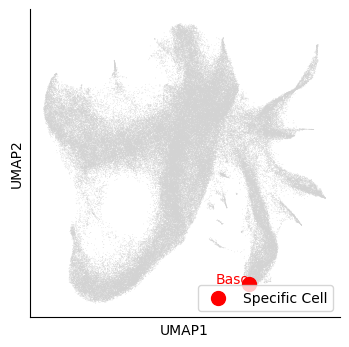

In [12]:
celltype = 'Baso'
celltype_mask = (adata.obs['Time_Point'] == '6.0') & (adata.obs['state_info'] == celltype)
adata_subset = adata[celltype_mask]

# Define the quantiles you want to compute
quantiles = [0, 0.25, 0.5, 0.75, 1]

# Compute the quantiles
computed_quantiles = np.quantile(adata_subset.obsm['X_umap'][:,1], quantiles)

print(f"Quantiles at {quantiles}: {computed_quantiles}")

np.random.seed(42) 
num_samples=1000

matches = (adata.obs['Time_Point'] == '2.0') & (adata.obs['state_info'] == 'undiff')
idx1 = np.where(matches)[0]
print(len(idx1))
subsampled_idx1 = np.random.choice(idx1, size=num_samples, replace=False)

matches = (adata.obs['Time_Point'] == '6.0') & (adata.obs['state_info'] == celltype) & (adata.obsm['X_umap'][:,1] <= computed_quantiles[1])
idx2 = np.where(matches)[0]
print(len(idx2))
subsampled_idx2 = np.random.choice(idx2, size=num_samples, replace=False)

# Extract the rows corresponding to idx1 and idx2
data_idx1 = dm_res['EigenVectors'].iloc[subsampled_idx1]
data_idx2 = dm_res['EigenVectors'].iloc[subsampled_idx2]

# Calculate the distance matrix between idx1 and idx2
distances = distance_matrix(data_idx1, data_idx2)

# Calculate the average distance from each cell in idx2 to all cells in idx1
average_distances = np.mean(distances, axis=0)

# Find the index of the cell in idx2 with the maximum average distance
max_avg_dist_index = np.argmax(average_distances)

# Get the actual index in the original DataFrame
furthest_cell_index = subsampled_idx2[max_avg_dist_index]
cell_name = adata.obs_names[furthest_cell_index]
print(cell_name)

terminal_dict[celltype] = cell_name
print(terminal_dict)

sc.pl.umap(adata, show=False)  # Set show=False to keep the plot open for further annotations

# Specific cell name to find
specific_cell_name = cell_name  # Replace with your actual cell name

# Find the index of the specific cell
cell_index = adata.obs_names.get_loc(specific_cell_name)

# Retrieve UMAP coordinates
umap_coordinates = adata.obsm['X_umap'][cell_index]

# Annotate the specific cell on the plot
plt.scatter(umap_coordinates[0], umap_coordinates[1], color='red', s=100, label='Specific Cell')
plt.text(umap_coordinates[0], umap_coordinates[1], celltype, color='red', ha='right')
plt.legend()
plt.show()

Mast

25575
1965
LK_d6_1_1:TAACTTCT-GCAGTCGA
{'Monocyte': 'd6_2_1:TACGCGAG-CAATTAGT', 'Neutrophil': 'LK_d6_2_2:ACCGTCGA-ATACTCTT', 'Baso': 'LK_d6_2_2:AAATAGCA-TGCCATCG', 'Mast': 'LK_d6_1_1:TAACTTCT-GCAGTCGA'}


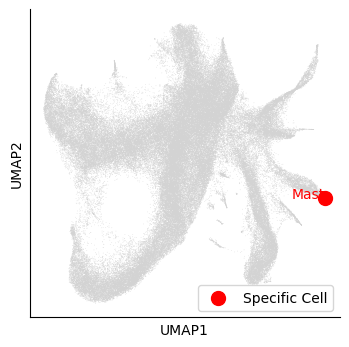

In [13]:
celltype = 'Mast'
celltype_mask = (adata.obs['Time_Point'] == '6.0') & (adata.obs['state_info'] == celltype)
adata_subset = adata[celltype_mask]

np.random.seed(42) 
num_samples=1000

matches = (adata.obs['Time_Point'] == '2.0') & (adata.obs['state_info'] == 'undiff')
idx1 = np.where(matches)[0]
print(len(idx1))
subsampled_idx1 = np.random.choice(idx1, size=num_samples, replace=False)

matches = (adata.obs['Time_Point'] == '6.0') & (adata.obs['state_info'] == celltype)
idx2 = np.where(matches)[0]
print(len(idx2))

# Extract the rows corresponding to idx1 and idx2
data_idx1 = dm_res['EigenVectors'].iloc[subsampled_idx1]
data_idx2 = dm_res['EigenVectors'].iloc[idx2]

# Calculate the distance matrix between idx1 and idx2
distances = distance_matrix(data_idx1, data_idx2)

# Calculate the average distance from each cell in idx2 to all cells in idx1
average_distances = np.mean(distances, axis=0)

# Find the index of the cell in idx2 with the maximum average distance
max_avg_dist_index = np.argmax(average_distances)

# Get the actual index in the original DataFrame
furthest_cell_index = idx2[max_avg_dist_index]
cell_name = adata.obs_names[furthest_cell_index]
print(cell_name)

terminal_dict[celltype] = cell_name
print(terminal_dict)

sc.pl.umap(adata, show=False)  # Set show=False to keep the plot open for further annotations

# Specific cell name to find
specific_cell_name = cell_name  # Replace with your actual cell name

# Find the index of the specific cell
cell_index = adata.obs_names.get_loc(specific_cell_name)

# Retrieve UMAP coordinates
umap_coordinates = adata.obsm['X_umap'][cell_index]

# Annotate the specific cell on the plot
plt.scatter(umap_coordinates[0], umap_coordinates[1], color='red', s=100, label='Specific Cell')
plt.text(umap_coordinates[0], umap_coordinates[1], celltype, color='red', ha='right')

plt.legend()
plt.show()

Erythroid

25575
433
LK_d6_2_2:CTAGACTA-CGCTAATA
{'Monocyte': 'd6_2_1:TACGCGAG-CAATTAGT', 'Neutrophil': 'LK_d6_2_2:ACCGTCGA-ATACTCTT', 'Baso': 'LK_d6_2_2:AAATAGCA-TGCCATCG', 'Mast': 'LK_d6_1_1:TAACTTCT-GCAGTCGA', 'Erythroid': 'LK_d6_2_2:CTAGACTA-CGCTAATA'}


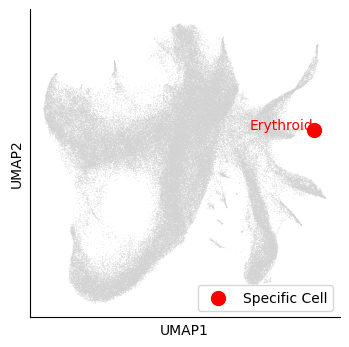

In [14]:
celltype = 'Erythroid'
celltype_mask = (adata.obs['Time_Point'] == '6.0') & (adata.obs['state_info'] == celltype)
adata_subset = adata[celltype_mask]

np.random.seed(42) 
num_samples=1000

matches = (adata.obs['Time_Point'] == '2.0') & (adata.obs['state_info'] == 'undiff')
idx1 = np.where(matches)[0]
print(len(idx1))
subsampled_idx1 = np.random.choice(idx1, size=num_samples, replace=False)

matches = (adata.obs['Time_Point'] == '6.0') & (adata.obs['state_info'] == celltype)
idx2 = np.where(matches)[0]
print(len(idx2))

# Extract the rows corresponding to idx1 and idx2
data_idx1 = dm_res['EigenVectors'].iloc[subsampled_idx1]
data_idx2 = dm_res['EigenVectors'].iloc[idx2]

# Calculate the distance matrix between idx1 and idx2
distances = distance_matrix(data_idx1, data_idx2)

# Calculate the average distance from each cell in idx2 to all cells in idx1
average_distances = np.mean(distances, axis=0)

# Find the index of the cell in idx2 with the maximum average distance
max_avg_dist_index = np.argmax(average_distances)

# Get the actual index in the original DataFrame
furthest_cell_index = idx2[max_avg_dist_index]
cell_name = adata.obs_names[furthest_cell_index]
print(cell_name)

terminal_dict[celltype] = cell_name
print(terminal_dict)

sc.pl.umap(adata, show=False)  # Set show=False to keep the plot open for further annotations

# Specific cell name to find
specific_cell_name = cell_name  # Replace with your actual cell name

# Find the index of the specific cell
cell_index = adata.obs_names.get_loc(specific_cell_name)

# Retrieve UMAP coordinates
umap_coordinates = adata.obsm['X_umap'][cell_index]

# Annotate the specific cell on the plot
plt.scatter(umap_coordinates[0], umap_coordinates[1], color='red', s=100, label='Specific Cell')
plt.text(umap_coordinates[0], umap_coordinates[1], celltype, color='red', ha='right')

plt.legend()
plt.show()


Meg

Quantiles at [0, 0.25, 0.5, 0.75, 1]: [ 2.05429435 11.13888693 11.99903393 12.8379488  14.49238396]
25575
342
d6_1_2:GTGAACTC-CCAACCGT
{'Monocyte': 'd6_2_1:TACGCGAG-CAATTAGT', 'Neutrophil': 'LK_d6_2_2:ACCGTCGA-ATACTCTT', 'Baso': 'LK_d6_2_2:AAATAGCA-TGCCATCG', 'Mast': 'LK_d6_1_1:TAACTTCT-GCAGTCGA', 'Erythroid': 'LK_d6_2_2:CTAGACTA-CGCTAATA', 'Meg': 'd6_1_2:GTGAACTC-CCAACCGT'}


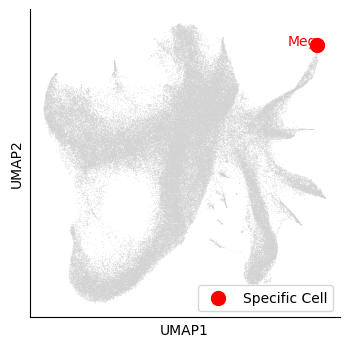

In [15]:
celltype = 'Meg'
celltype_mask = (adata.obs['Time_Point'] == '6.0') & (adata.obs['state_info'] == celltype)
adata_subset = adata[celltype_mask]

# Define the quantiles you want to compute
quantiles = [0, 0.25, 0.5, 0.75, 1]

# Compute the quantiles
computed_quantiles = np.quantile(adata_subset.obsm['X_umap'][:,1], quantiles)

print(f"Quantiles at {quantiles}: {computed_quantiles}")

np.random.seed(42) 
num_samples=1000

matches = (adata.obs['Time_Point'] == '2.0') & (adata.obs['state_info'] == 'undiff')
idx1 = np.where(matches)[0]
print(len(idx1))
subsampled_idx1 = np.random.choice(idx1, size=num_samples, replace=False)

matches = (adata.obs['Time_Point'] == '6.0') & (adata.obs['state_info'] == celltype) & (adata.obsm['X_umap'][:,1] >= computed_quantiles[3])
idx2 = np.where(matches)[0]
print(len(idx2))

# Extract the rows corresponding to idx1 and idx2
data_idx1 = dm_res['EigenVectors'].iloc[subsampled_idx1]
data_idx2 = dm_res['EigenVectors'].iloc[idx2]

# Calculate the distance matrix between idx1 and idx2
distances = distance_matrix(data_idx1, data_idx2)

# Calculate the average distance from each cell in idx2 to all cells in idx1
average_distances = np.mean(distances, axis=0)

# Find the index of the cell in idx2 with the maximum average distance
max_avg_dist_index = np.argmax(average_distances)

# Get the actual index in the original DataFrame
furthest_cell_index = idx2[max_avg_dist_index]
cell_name = adata.obs_names[furthest_cell_index]
print(cell_name)

terminal_dict[celltype] = cell_name
print(terminal_dict)

sc.pl.umap(adata, show=False)  # Set show=False to keep the plot open for further annotations

# Specific cell name to find
specific_cell_name = cell_name  # Replace with your actual cell name

# Find the index of the specific cell
cell_index = adata.obs_names.get_loc(specific_cell_name)

# Retrieve UMAP coordinates
umap_coordinates = adata.obsm['X_umap'][cell_index]

# Annotate the specific cell on the plot
plt.scatter(umap_coordinates[0], umap_coordinates[1], color='red', s=100, label='Specific Cell')
plt.text(umap_coordinates[0], umap_coordinates[1], celltype, color='red', ha='right')

plt.legend()
plt.show()

EOS

25575
351
LK_d6_2_1:GCTATGGG-TGGTTTCT
{'Monocyte': 'd6_2_1:TACGCGAG-CAATTAGT', 'Neutrophil': 'LK_d6_2_2:ACCGTCGA-ATACTCTT', 'Baso': 'LK_d6_2_2:AAATAGCA-TGCCATCG', 'Mast': 'LK_d6_1_1:TAACTTCT-GCAGTCGA', 'Erythroid': 'LK_d6_2_2:CTAGACTA-CGCTAATA', 'Meg': 'd6_1_2:GTGAACTC-CCAACCGT', 'Eos': 'LK_d6_2_1:GCTATGGG-TGGTTTCT'}


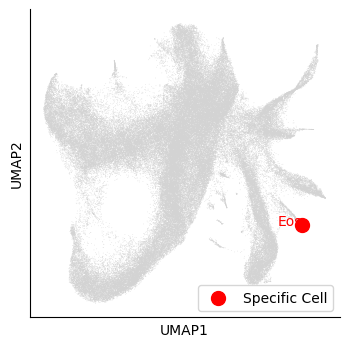

25575
84
d6_1_2:CTAGTAGG-TTTATCAC
{'Monocyte': 'd6_2_1:TACGCGAG-CAATTAGT', 'Neutrophil': 'LK_d6_2_2:ACCGTCGA-ATACTCTT', 'Baso': 'LK_d6_2_2:AAATAGCA-TGCCATCG', 'Mast': 'LK_d6_1_1:TAACTTCT-GCAGTCGA', 'Erythroid': 'LK_d6_2_2:CTAGACTA-CGCTAATA', 'Meg': 'd6_1_2:GTGAACTC-CCAACCGT', 'Eos': 'LK_d6_2_1:GCTATGGG-TGGTTTCT', 'Ccr7_DC': 'd6_1_2:CTAGTAGG-TTTATCAC'}


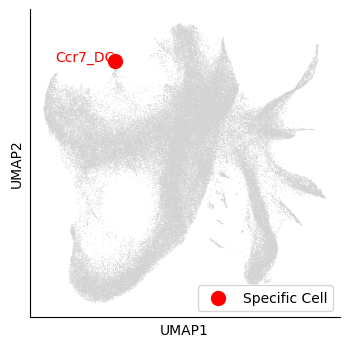

In [16]:
celltype = 'Eos'
celltype_mask = (adata.obs['Time_Point'] == '6.0') & (adata.obs['state_info'] == celltype)
adata_subset = adata[celltype_mask]

np.random.seed(42) 
num_samples=1000

matches = (adata.obs['Time_Point'] == '2.0') & (adata.obs['state_info'] == 'undiff')
idx1 = np.where(matches)[0]
print(len(idx1))
subsampled_idx1 = np.random.choice(idx1, size=num_samples, replace=False)

matches = (adata.obs['Time_Point'] == '6.0') & (adata.obs['state_info'] == celltype)
idx2 = np.where(matches)[0]
print(len(idx2))

# Extract the rows corresponding to idx1 and idx2
data_idx1 = dm_res['EigenVectors'].iloc[subsampled_idx1]
data_idx2 = dm_res['EigenVectors'].iloc[idx2]

# Calculate the distance matrix between idx1 and idx2
distances = distance_matrix(data_idx1, data_idx2)

# Calculate the average distance from each cell in idx2 to all cells in idx1
average_distances = np.mean(distances, axis=0)

# Find the index of the cell in idx2 with the maximum average distance
max_avg_dist_index = np.argmax(average_distances)

# Get the actual index in the original DataFrame
furthest_cell_index = idx2[max_avg_dist_index]
cell_name = adata.obs_names[furthest_cell_index]
print(cell_name)

terminal_dict[celltype] = cell_name
print(terminal_dict)

sc.pl.umap(adata, show=False)  # Set show=False to keep the plot open for further annotations

# Specific cell name to find
specific_cell_name = cell_name  # Replace with your actual cell name

# Find the index of the specific cell
cell_index = adata.obs_names.get_loc(specific_cell_name)

# Retrieve UMAP coordinates
umap_coordinates = adata.obsm['X_umap'][cell_index]

# Annotate the specific cell on the plot
plt.scatter(umap_coordinates[0], umap_coordinates[1], color='red', s=100, label='Specific Cell')
plt.text(umap_coordinates[0], umap_coordinates[1], celltype, color='red', ha='right')

plt.legend()
plt.show()

#Ccr7_DC
celltype = 'Ccr7_DC'
celltype_mask = (adata.obs['Time_Point'] == '6.0') & (adata.obs['state_info'] == celltype)
adata_subset = adata[celltype_mask]

np.random.seed(42) 
num_samples=1000

matches = (adata.obs['Time_Point'] == '2.0') & (adata.obs['state_info'] == 'undiff')
idx1 = np.where(matches)[0]
print(len(idx1))
subsampled_idx1 = np.random.choice(idx1, size=num_samples, replace=False)

matches = (adata.obs['Time_Point'] == '6.0') & (adata.obs['state_info'] == celltype)
idx2 = np.where(matches)[0]
print(len(idx2))

# Extract the rows corresponding to idx1 and idx2
data_idx1 = dm_res['EigenVectors'].iloc[subsampled_idx1]
data_idx2 = dm_res['EigenVectors'].iloc[idx2]

# Calculate the distance matrix between idx1 and idx2
distances = distance_matrix(data_idx1, data_idx2)

# Calculate the average distance from each cell in idx2 to all cells in idx1
average_distances = np.mean(distances, axis=0)

# Find the index of the cell in idx2 with the maximum average distance
max_avg_dist_index = np.argmax(average_distances)

# Get the actual index in the original DataFrame
furthest_cell_index = idx2[max_avg_dist_index]
cell_name = adata.obs_names[furthest_cell_index]
print(cell_name)

terminal_dict[celltype] = cell_name
print(terminal_dict)

sc.pl.umap(adata, show=False)  # Set show=False to keep the plot open for further annotations

# Specific cell name to find
specific_cell_name = cell_name  # Replace with your actual cell name

# Find the index of the specific cell
cell_index = adata.obs_names.get_loc(specific_cell_name)

# Retrieve UMAP coordinates
umap_coordinates = adata.obsm['X_umap'][cell_index]

# Annotate the specific cell on the plot
plt.scatter(umap_coordinates[0], umap_coordinates[1], color='red', s=100, label='Specific Cell')
plt.text(umap_coordinates[0], umap_coordinates[1], celltype, color='red', ha='right')

plt.legend()
plt.show()

Find a undifferentiated cell

In [18]:
terminal_values = np.array(list(terminal_dict.values()))
matches = np.isin(adata.obs_names, terminal_values)
idx1 = np.where(matches)

matches = (adata.obs['Time_Point'] == '2.0') & (adata.obs['state_info'] == 'undiff') & (adata.obsm['X_umap'][:,1] >= 14) & (adata.obsm['X_umap'][:,0] >= 5) & (adata.obsm['X_umap'][:,0] <= 6)
idx2 = np.where(matches)[0]
print(len(idx2))

# Extract the rows corresponding to idx1 and idx2
data_idx1 = dm_res['EigenVectors'].iloc[idx1]
data_idx2 = dm_res['EigenVectors'].iloc[idx2]

# Calculate the distance matrix between idx1 and idx2
distances = distance_matrix(data_idx1, data_idx2)

# Calculate the average distance from each cell in idx2 to all cells in idx1
average_distances = np.mean(distances, axis=0)

# Find the index of the cell in idx2 with the maximum average distance
max_avg_dist_index = np.argmax(average_distances)

# Get the actual index in the original DataFrame
furthest_cell_index = idx2[max_avg_dist_index]
cell_name = adata.obs_names[furthest_cell_index]
print(cell_name)

undiff_cell = cell_name

1219
LSK_d2_2:AAAGCCCG-GTCATATT


Plotting all the terminal cells

In [20]:
print(np.sort(adata.obs['state_info'].unique()))
print(adata.uns['state_info_colors'])

celltype_unique = np.sort(adata.obs['state_info'].unique())
celltype_unique = celltype_unique[celltype_unique != "undiff"]
color_dict = {}
for i in range(len(celltype_unique)):
    color_dict[celltype_unique[i]] = adata.uns['state_info_colors'][i]

print(color_dict)
  # Set show=False to keep the plot open for further annotations

['Baso' 'Ccr7_DC' 'Eos' 'Erythroid' 'Mast' 'Meg' 'Monocyte' 'Neutrophil'
 'undiff']
['#1f77b4' '#ff7f0e' '#279e68' '#d62728' '#8c564b' '#e377c2' '#b5bd61'
 '#17becf' '#ffbb78']
{'Baso': '#1f77b4', 'Ccr7_DC': '#ff7f0e', 'Eos': '#279e68', 'Erythroid': '#d62728', 'Mast': '#8c564b', 'Meg': '#e377c2', 'Monocyte': '#b5bd61', 'Neutrophil': '#17becf'}


[ 5.87614  15.597418]


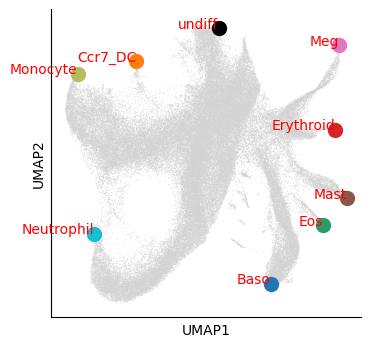

In [22]:
sc.pl.umap(adata, show=False)  # Set show=False to keep the plot open for further annotations
for celltype in celltype_unique:
    specific_cell_name = terminal_dict[celltype]

    # Find the index of the specific cell
    cell_index = adata.obs_names.get_loc(specific_cell_name)
    
    # Retrieve UMAP coordinates
    umap_coordinates = adata.obsm['X_umap'][cell_index]
    
    # Annotate the specific cell on the plot
    plt.scatter(umap_coordinates[0], umap_coordinates[1], color=color_dict[celltype], s=100, label=celltype)
    plt.text(umap_coordinates[0], umap_coordinates[1], celltype, color='red', ha='right')

# Find the index of the specific cell
cell_index = adata.obs_names.get_loc(undiff_cell)

# Retrieve UMAP coordinates
umap_coordinates = adata.obsm['X_umap'][cell_index]
print(umap_coordinates)
# Annotate the specific cell on the plot
plt.scatter(umap_coordinates[0], umap_coordinates[1], color='black', s=100, label='undiff')
plt.text(umap_coordinates[0], umap_coordinates[1], 'undiff', color='red', ha='right')
plt.axis('on') 
plt.show()


run panlantir

In [23]:
terminal_series = pd.Series(terminal_dict)
terminal_series = pd.Series(terminal_series.index.values, index=terminal_series.values)
print(terminal_series)


d6_2_1:TACGCGAG-CAATTAGT         Monocyte
LK_d6_2_2:ACCGTCGA-ATACTCTT    Neutrophil
LK_d6_2_2:AAATAGCA-TGCCATCG          Baso
LK_d6_1_1:TAACTTCT-GCAGTCGA          Mast
LK_d6_2_2:CTAGACTA-CGCTAATA     Erythroid
d6_1_2:GTGAACTC-CCAACCGT              Meg
LK_d6_2_1:GCTATGGG-TGGTTTCT           Eos
d6_1_2:CTAGTAGG-TTTATCAC          Ccr7_DC
dtype: object


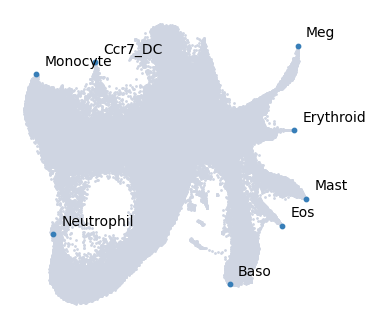

In [24]:

palantir.plot.highlight_cells_on_umap(adata, terminal_series)
plt.show()

In [25]:
adata

AnnData object with n_obs × n_vars = 129929 × 25289
    obs: 'n_counts', 'Time_Point', 'Source', 'Well', 'mito_frac', 'time_info', 'state_info', 'precomputed_fate_bias', 'selected_clonal_cells', 'Gata1_states'
    var: 'highly_variable'
    uns: 'clonal_time_points', 'data_des', 'max_mito', 'min_tot', 'neighbors', 'state_info_colors', 'time_info_colors', 'time_ordering', 'umap', 'Time_Point_colors', 'DM_EigenValues'
    obsm: 'X_clone', 'X_emb', 'X_pca', 'X_umap', 'DM_EigenVectors'
    obsp: 'DM_Kernel', 'DM_Similarity'

In [26]:

ms_data = palantir.utils.determine_multiscale_space(adata)
undiff_cell

'LSK_d2_2:AAAGCCCG-GTCATATT'

In [27]:

pr_res = palantir.core.run_palantir(
    adata, 
    early_cell=undiff_cell, 
    num_waypoints=500, 
    terminal_states=terminal_series,
    use_early_cell_as_start=True
)

Sampling and flocking waypoints...
Time for determining waypoints: 0.19833237727483113 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 6.565179510911306 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9997
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


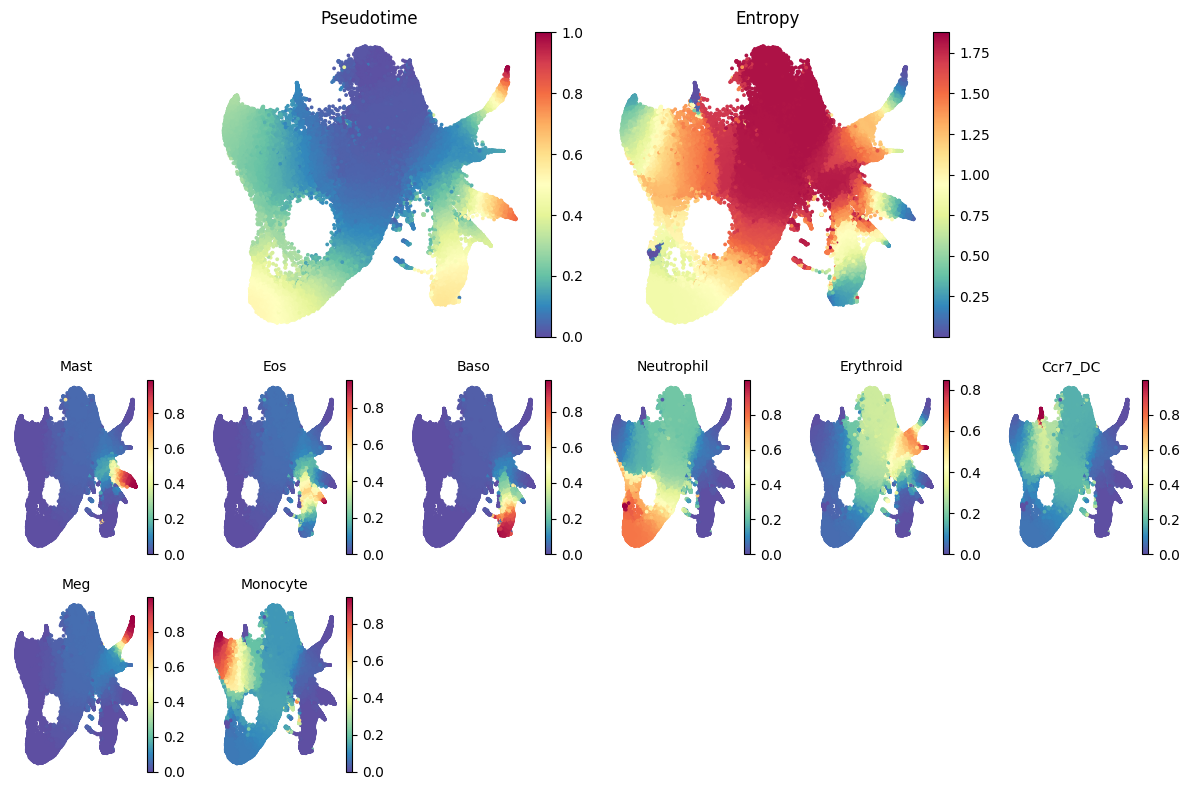

In [28]:
palantir.plot.plot_palantir_results(adata, s=3)
plt.show()


save the data

In [30]:
adata

AnnData object with n_obs × n_vars = 129929 × 25289
    obs: 'n_counts', 'Time_Point', 'Source', 'Well', 'mito_frac', 'time_info', 'state_info', 'precomputed_fate_bias', 'selected_clonal_cells', 'Gata1_states', 'palantir_pseudotime', 'palantir_entropy'
    var: 'highly_variable'
    uns: 'clonal_time_points', 'data_des', 'max_mito', 'min_tot', 'neighbors', 'state_info_colors', 'time_info_colors', 'time_ordering', 'umap', 'Time_Point_colors', 'DM_EigenValues', 'palantir_waypoints'
    obsm: 'X_clone', 'X_emb', 'X_pca', 'X_umap', 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'palantir_fate_probabilities'
    obsp: 'DM_Kernel', 'DM_Similarity'

In [29]:
#save the result
adata.write_h5ad('/home/yzhao4/branch_point_prediction/Larrydata/Data/Complete_LARRY_dataset_adata_preprocessed_barcodes_palantir.h5ad')
